<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/Week9%2C10(GuidedPropagation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN progressively transforms input images into hierarchical feature representations.
Early layers capture basic visual features, while deeper layers capture semantic information.
Pooling layers reduce computational complexity while preserving important features.
Visualization confirms that the model is learning relevant patterns for classification.

Train shape: (1080, 64, 64, 3)
Test shape: (120, 64, 64, 3)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,662 (3.14 MB)

 Trainable params: 822,662 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.2241 - loss: 1.7736
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.5222 - loss: 1.3426
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.6991 - loss: 0.8971
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.7769 - loss: 0.6684
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.8491 - loss: 0.4775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


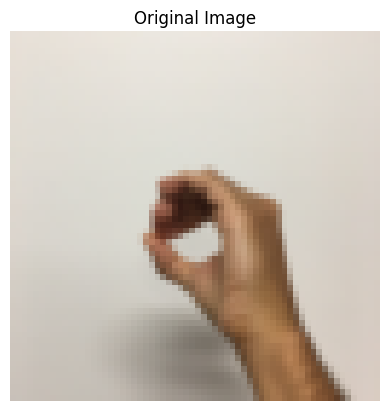

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


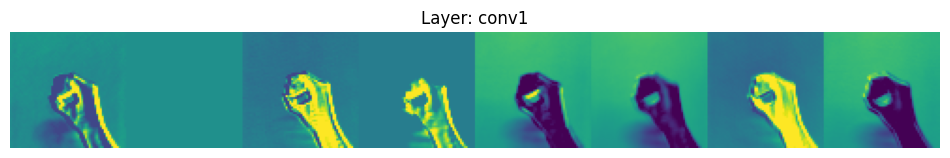

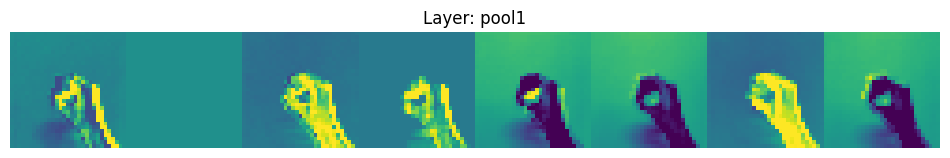

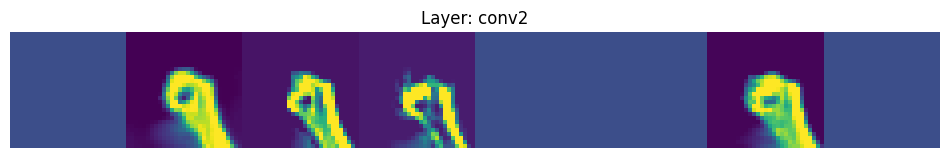

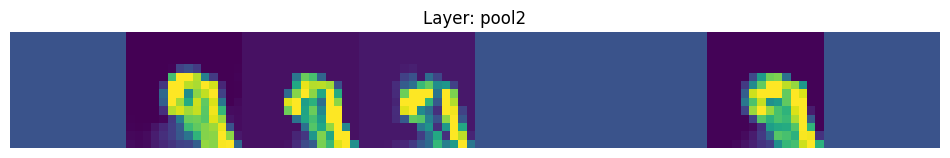

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# ----------------------------
# 1. Load Dataset
# ----------------------------
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ----------------------------
# 2. Preprocessing
# ----------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension if grayscale
if len(X_train.shape) == 3:
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

# ----------------------------
# 3. Build CNN Model
# ----------------------------
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3,3), activation='relu', name="conv1"),
    layers.MaxPooling2D((2,2), name="pool1"),

    layers.Conv2D(64, (3,3), activation='relu', name="conv2"),
    layers.MaxPooling2D((2,2), name="pool2"),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')   # change if needed
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ----------------------------
# 4. Train Model
# ----------------------------
model.fit(X_train, Y_train, epochs=5, batch_size=32)

# ----------------------------
# 5. Build Feature Map Model (FIXED)
# ----------------------------
# Force model build
_ = model.predict(X_train[:1])

# Extract conv + pooling layers
layer_outputs = [layer.output for layer in model.layers
                 if "conv" in layer.name or "pool" in layer.name]

feature_map_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

# ----------------------------
# 6. Select Test Image
# ----------------------------
index = 0   # change to visualize different image
img = X_test[index]

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

# ----------------------------
# 7. Get Feature Maps
# ----------------------------
feature_maps = feature_map_model.predict(img)

# ----------------------------
# 8. Visualization Function
# ----------------------------
def plot_feature_maps(feature_maps, layer_names):
    for fmap, layer_name in zip(feature_maps, layer_names):
        num_filters = fmap.shape[-1]
        size = fmap.shape[1]

        # Show max 8 filters
        n_filters = min(num_filters, 8)

        display_grid = np.zeros((size, size * n_filters))

        for i in range(n_filters):
            x = fmap[0, :, :, i]

            # Normalize for visualization
            x -= x.mean()
            x /= (x.std() + 1e-5)
            x *= 64
            x += 128
            x = np.clip(x, 0, 255).astype('uint8')

            display_grid[:, i * size : (i + 1) * size] = x

        plt.figure(figsize=(12, 3))
        plt.title(f"Layer: {layer_name}")
        plt.imshow(display_grid, cmap='viridis')
        plt.axis('off')
        plt.show()

# ----------------------------
# 9. Plot Feature Maps
# ----------------------------
layer_names = [layer.name for layer in model.layers
               if "conv" in layer.name or "pool" in layer.name]

plot_feature_maps(feature_maps, layer_names)

In [ ]:
# 10. Predict on the test set and identify misclassified images
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

misclassified_indices = np.where(predicted_classes != Y_test)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Total misclassified images: 39


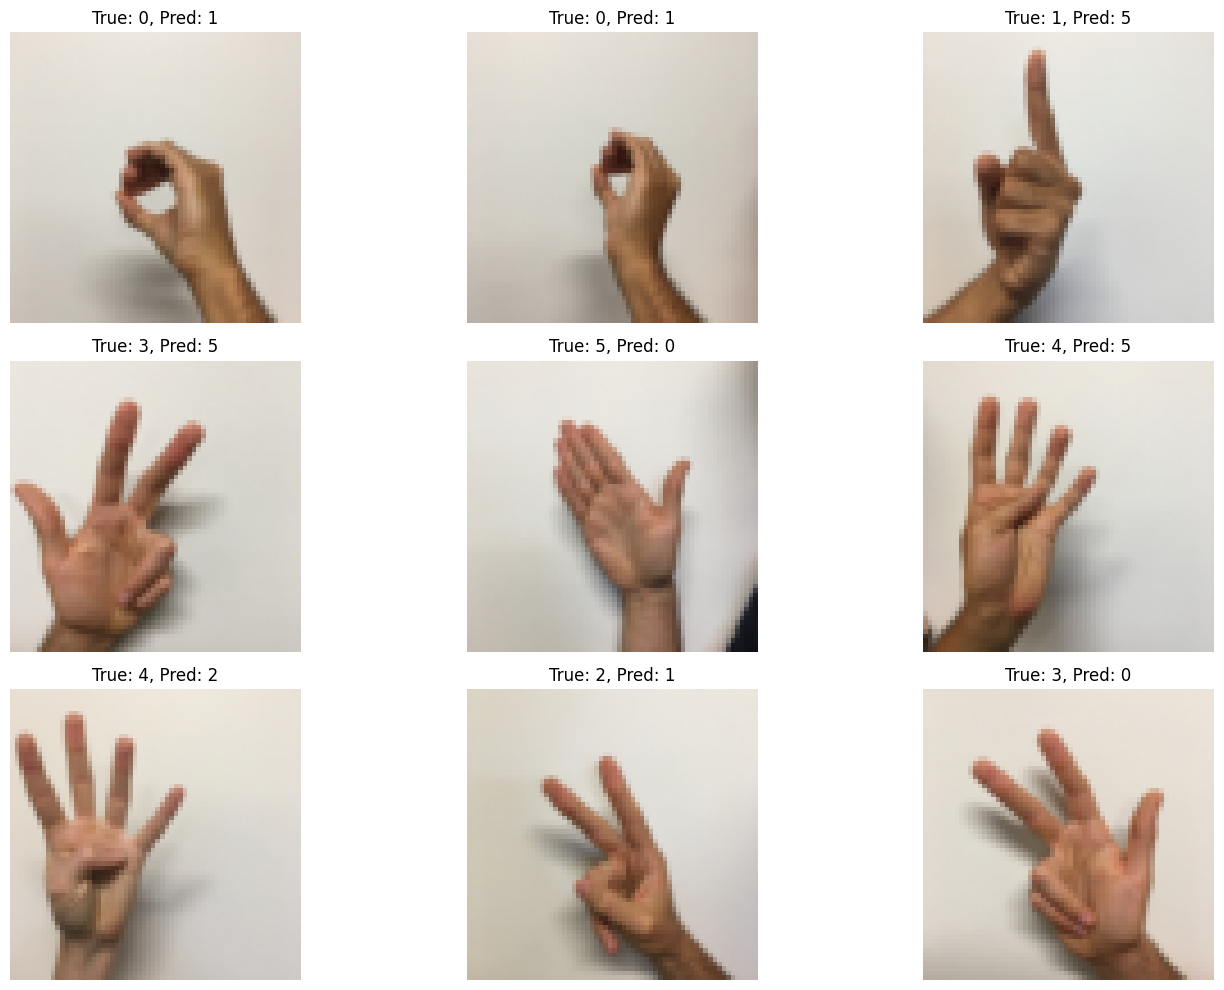

In [ ]:
# 11. Visualize a few misclassified images

plt.figure(figsize=(15, 10))
num_images_to_display = min(9, len(misclassified_indices)) # Display up to 9 misclassified images

for i in range(num_images_to_display):
    index = misclassified_indices[i]
    plt.subplot(3, 3, i + 1)

    # Handle grayscale vs. color images
    if X_test.shape[-1] == 1: # Grayscale
        plt.imshow(X_test[index].reshape(X_test.shape[1], X_test.shape[2]), cmap='gray')
    else: # Color
        plt.imshow(X_test[index])

    plt.title(f"True: {Y_test[index]}, Pred: {predicted_classes[index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)



It shows which input pixels positively influence the model’s prediction by modifying how gradients flow backward through ReLU.


Train shape: (1080, 64, 64, 3)
Test shape: (120, 64, 64, 3)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,926 (6.20 MB)

 Trainable params: 1,625,926 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.2697 - loss: 1.7972 - val_accuracy: 0.3565 - val_loss: 1.6244
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.5069 - loss: 1.3411 - val_accuracy: 0.5463 - val_loss: 1.1944
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 0.6620 - loss: 0.9480 - val_accuracy: 0.6296 - val_loss: 0.9176
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.7639 - loss: 0.6746 - val_accuracy: 0.6574 - val_loss: 0.9151
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step - accuracy: 0.8368 - loss: 0.5049 - val_accuracy: 0.7778 - val_loss: 0.6730
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8250 - loss: 0.5981

Test Accuracy: 0.824999988079071


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step



True Label: 0
Predicted Label: 0
Confidence: 0.88237906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Shapes:
Conv1: (1, 62, 62, 32)
Pool1: (1, 31, 31, 32)
Conv2: (1, 29, 29, 64)
Pool2: (1, 14, 14, 64)


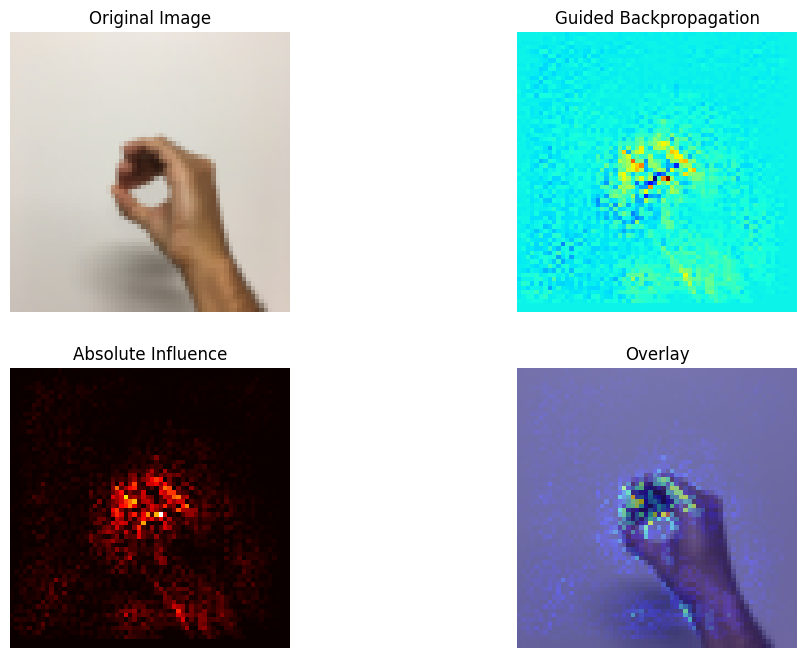

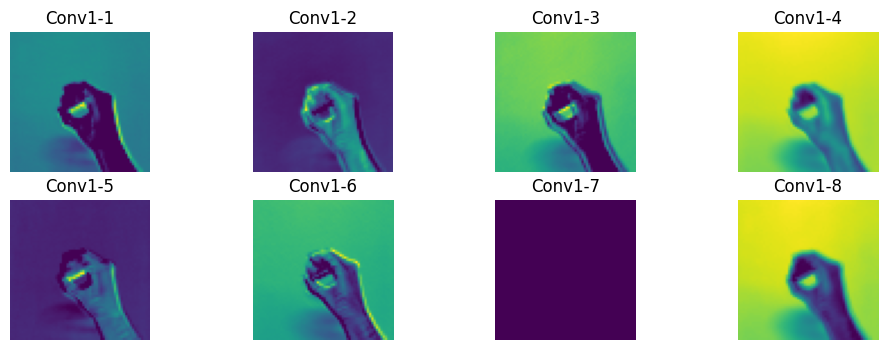

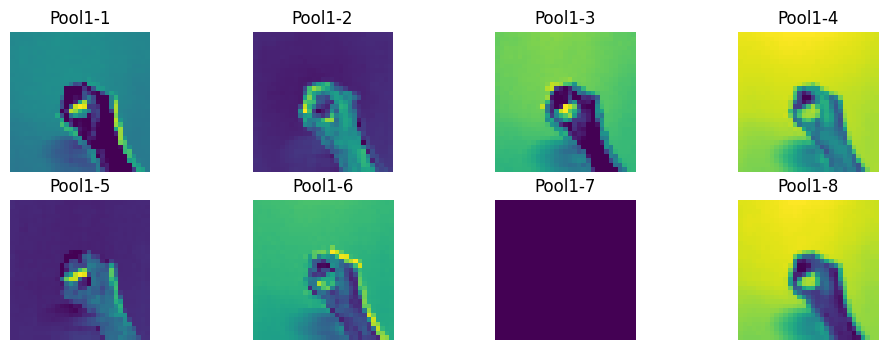

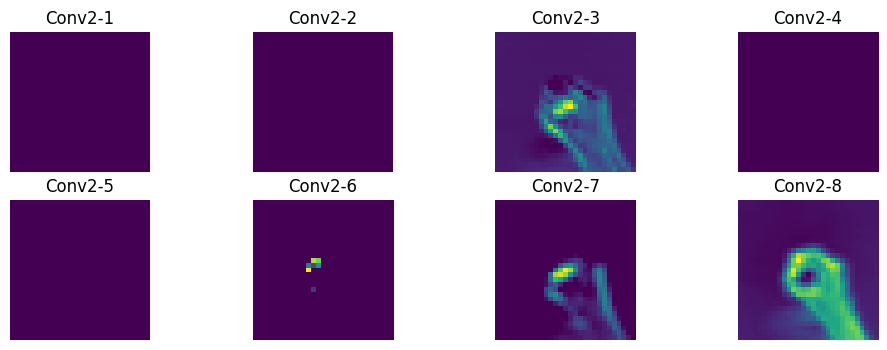

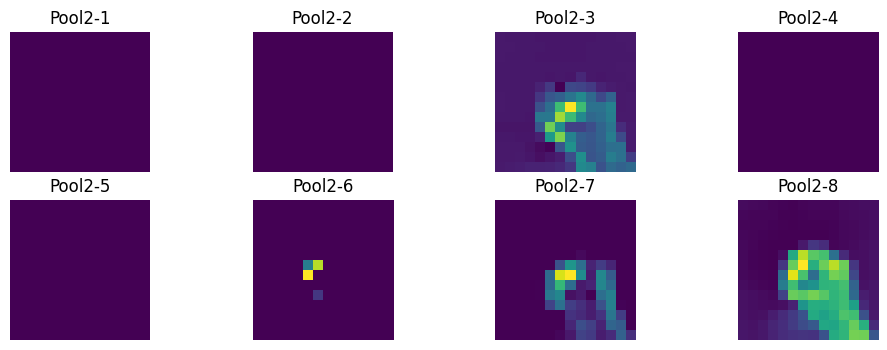


Gradient Stats:
Min: -0.029336575
Max: 0.99999976
Mean: 0.12505285
Std: 0.17881683

Top Influential Pixels:
1: (33,34) -> 1.000000
2: (29,26) -> 0.816075
3: (30,28) -> 0.767437
4: (33,33) -> 0.766068
5: (35,30) -> 0.750220
6: (33,31) -> 0.000000
7: (29,38) -> 0.710928
8: (31,27) -> 0.708245
9: (31,40) -> 0.704299
10: (27,35) -> 0.700862


In [ ]:
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

# ----------------------------
# 1. Load Dataset (.h5)
# ----------------------------
with h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

with h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ----------------------------
# 2. Preprocessing
# ----------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Ensure channel dimension
if len(X_train.shape) == 3:
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

num_classes = len(np.unique(Y_train))

# ----------------------------
# 3. Build CNN Model
# ----------------------------
base_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3,3), activation='relu', name='conv1'),
    layers.MaxPooling2D((2,2), name='pool1'),

    layers.Conv2D(64, (3,3), activation='relu', name='conv2'),
    layers.MaxPooling2D((2,2), name='pool2'),

    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='fc1'),
    layers.Dense(num_classes, activation='softmax', name='output')
])

base_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

base_model.summary()

# ----------------------------
# 4. Train Model
# ----------------------------
history = base_model.fit(X_train, Y_train,
                         epochs=5,
                         batch_size=32,
                         validation_split=0.2)

test_loss, test_acc = base_model.evaluate(X_test, Y_test)
print("\nTest Accuracy:", test_acc)

# Force build
_ = base_model.predict(X_test[:1])

# ----------------------------
# 5. Intermediate Models
# ----------------------------
conv1_model = Model(base_model.inputs, base_model.get_layer("conv1").output)
pool1_model = Model(base_model.inputs, base_model.get_layer("pool1").output)
conv2_model = Model(base_model.inputs, base_model.get_layer("conv2").output)
pool2_model = Model(base_model.inputs, base_model.get_layer("pool2").output)

# ----------------------------
# 6. Guided ReLU
# ----------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, tf.float32) * tf.cast(x > 0, tf.float32) * dy
    return tf.nn.relu(x), grad

# ----------------------------
# 7. Build Guided Model
# ----------------------------
def build_guided_model():
    inputs = layers.Input(shape=X_train.shape[1:])

    x = layers.Conv2D(32, (3,3))(inputs)
    x = layers.Activation(guided_relu)(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3))(x)
    x = layers.Activation(guided_relu)(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.Activation(guided_relu)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

guided_model = build_guided_model()
guided_model.set_weights(base_model.get_weights())

# ----------------------------
# 8. Select Image
# ----------------------------
idx = 0
input_image = X_test[idx:idx+1]
true_label = Y_test[idx]

# Prediction
pred = guided_model(input_image)
pred_class = np.argmax(pred[0])
print("\nTrue Label:", true_label)
print("Predicted Label:", pred_class)
print("Confidence:", pred[0][pred_class].numpy())

# ----------------------------
# 9. Intermediate Outputs
# ----------------------------
conv1_out = conv1_model.predict(input_image)
pool1_out = pool1_model.predict(input_image)
conv2_out = conv2_model.predict(input_image)
pool2_out = pool2_model.predict(input_image)

print("\nShapes:")
print("Conv1:", conv1_out.shape)
print("Pool1:", pool1_out.shape)
print("Conv2:", conv2_out.shape)
print("Pool2:", pool2_out.shape)

# ----------------------------
# 10. Guided Backpropagation
# ----------------------------
input_tensor = tf.convert_to_tensor(input_image)

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    outputs = guided_model(input_tensor)
    target = outputs[:, pred_class]

grads = tape.gradient(target, input_tensor)[0].numpy()

# Absolute gradients
abs_grads = np.abs(grads[:,:,0])

# ----------------------------
# 11. Normalize
# ----------------------------
def normalize(x):
    x -= x.min()
    x /= (x.max() + 1e-8)
    return x

guided_map = normalize(grads[:,:,0])
abs_map = normalize(abs_grads)

# ----------------------------
# 12. Visualization
# ----------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(input_image[0])
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(guided_map, cmap='jet')
plt.title("Guided Backpropagation")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(abs_map, cmap='hot')
plt.title("Absolute Influence")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(input_image[0])
plt.imshow(abs_map, cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis('off')

plt.show()

# ----------------------------
# 13. Feature Map Visualization
# ----------------------------
def show_maps(fmaps, title):
    n = min(fmaps.shape[-1], 8)
    plt.figure(figsize=(12,4))
    for i in range(n):
        plt.subplot(2,4,i+1)
        plt.imshow(fmaps[0,:,:,i], cmap='viridis')
        plt.title(f"{title}-{i+1}")
        plt.axis('off')
    plt.show()

show_maps(conv1_out, "Conv1")
show_maps(pool1_out, "Pool1")
show_maps(conv2_out, "Conv2")
show_maps(pool2_out, "Pool2")

# ----------------------------
# 14. Numerical Analysis
# ----------------------------
print("\nGradient Stats:")
print("Min:", grads.min())
print("Max:", grads.max())
print("Mean:", grads.mean())
print("Std:", grads.std())

top_k = 10
indices = np.argsort(abs_grads.ravel())[::-1][:top_k]
rows, cols = np.unravel_index(indices, abs_grads.shape)

print("\nTop Influential Pixels:")
for i, (r,c) in enumerate(zip(rows, cols)):
    print(f"{i+1}: ({r},{c}) -> {grads[r,c,0]:.6f}")

1. Important Pixels Highlighted
Only relevant regions (hand/fingers) are bright
Background mostly suppressed

👉 Model focuses on meaningful features

🔹 2. Noise Reduction
Compared to normal gradients:
Guided Backprop is cleaner
Less scattered noise
🔹 3. Edge Sensitivity
Strong activation around:
Finger boundaries
Gesture contours

👉 Model relies on shape structure

🔹 4. Positive Influence Only
Only pixels that increase prediction confidence are shown

👉 Unlike vanilla gradients, negative influence is removed

🔹 5. Model Understanding
CNN is:
Not looking at entire image
Only focusing on discriminative regions
🔹 6. Dataset Insight
For sign language:
Fingers & hand orientation dominate prediction
Background is ignored → good generalization
FINAL CONCLUSION
Guided Backpropagation provides fine-grained pixel-level importance
Helps interpret CNN decisions
Confirms that model is learning correct spatial features